In [ ]:
# ====================================================================================
# Copyright (c) 2026 [Haitham Sobhy]

# Permission is hereby granted, free of charge, to academic and non-profit
# researchers to inspect, run, and evaluate this software solely for non-profit
# academic research and peer-review evaluation purposes.

# MANDATORY CITATION REQUIREMENT:
# Any academic or non-profit usage, evaluation, or reference to this software
# MUST cite the following work:
# "Shetti-AI: Precise prediction of protein sequence mutational landscapes to
# accelerate functional assays (Under Revision)"

# RESTRICTIONS & PERMISSION REQUIREMENTS:

# 1. NO COMMERCIAL OR R&D USE: Any use, modification, integration, or testing by
#    or on behalf of commercial entities, for-profit corporations, or corporate
#    Research & Development (R&D) departments is STRICTLY PROHIBITED.

# 2. PRIOR PERMISSION REQUIRED: No part of this codebase, scripts, or algorithms
#    may be copied, modified, redistributed, or incorporated into other projects
#    without explicit prior written permission from the copyright holder.

# 3. COMMERCIAL LICENSING: For commercial inquiries, corporate R&D licensing,
#    or permission requests, please contact: [ hsobhy at live dot com ]

# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED.
# ====================================================================================

In [ ]:
# Lambda model

In [ ]:
# =============================================================
# BIOLOGICAL MOTIF EVOLUTION / GENERATION ENGINE
# LAMBDA MODEL
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# =============================================================
# AMINO-ACID DEFINITIONS
# =============================================================

AA_LIST = list("ARNDCEQGHILKMFPSTWYV")
AA_IDX = {aa: i for i, aa in enumerate(AA_LIST)}

N_AA = len(AA_LIST)


# =============================================================
# PHYSICOCHEMICAL PROPERTY MATRIX
# =============================================================
#
# Columns:
#
#  0 Charge
#  1 Hydropathy
#  2 Polarity
#  3 Volume
#  4 Flexibility
#  5 Aromaticity
#  6 Sulfur Content
#  7 Reactivity
#  8 Hydrogen Bonding
#  9 Alpha Helix Propensity
# 10 Beta Sheet Propensity
# 11 Turn Propensity
# 12 Disorder Propensity
# 13 General PTM
# 14 Phosphorylation
# 15 Acetylation
# 16 Metal Binding
# 17 Protein Interaction
#
# Values supplied by the user are already mapped to [-1, +1].
#
# NOTE:
# The original code described this as a "14D" representation,
# but the supplied table contains 18 columns.
#
# Therefore this implementation correctly uses 18 dimensions.
# =============================================================

AA_PROPS = {
    'A': [0, 0.4, -0.42, -0.68, -0.21, -1, -1, -1, -0.33, 0.65, 0.12, -0.56, -0.75, -1, -1, -1, -1, -0.2],
    'R': [1, -1, 0.75, 0.43, 0.32, -1, -1, 0, 0.85, 0.1, -0.35, -0.22, 0, 0, -1, 1, -1, 1],
    'N': [0, -0.78, 0.9, -0.34, 0.15, -1, -1, 0, 0.85, -0.45, -0.35, 0.48, 0.3, 0, -1, -1, -1, 0.5],
    'D': [-1, -0.78, 0.9, -0.37, 0.42, -1, -1, 0, 0.85, 0.12, -0.7, 0.52, 0.5, -1, -1, -1, 1, 0.5],
    'C': [0, 0.51, -0.3, -0.41, -0.3, -1, 1, 1, -0.33, -0.3, 0.5, 0.18, -0.6, 0, -1, -1, 1, 0],
    'E': [-1, -0.78, 0.9, -0.05, 0.28, -1, -1, 0, 0.85, 0.8, -0.8, -0.4, 0.4, -1, -1, -1, 1, 0.5],
    'Q': [0, -0.78, 0.9, 0, 0.22, -1, -1, 0, 0.85, 0.4, -0.1, -0.22, 0.2, 0, -1, -1, -1, 0.5],
    'G': [0, -0.18, -0.05, -1, 0.9, -1, -1, -1, -0.33, -0.8, -0.5, 1, 0.8, -1, -1, -1, -1, 0],
    'H': [0, -0.71, 0.6, 0.19, -0.5, 1, -1, 0, 0.85, 0.3, -0.2, -0.22, -0.1, 0, 0, -1, 1, 0.5],
    'I': [0, 1, -1, 0.34, 0.1, -1, -1, -1, -0.33, 0.1, 0.8, -0.8, -0.8, -1, -1, -1, -1, 0],
    'L': [0, 0.84, -1, 0.34, -0.25, -1, -1, -1, -0.33, 0.7, 0.4, -0.56, -0.7, -1, -1, -1, -1, 0],
    'K': [1, -0.87, 0.75, 0.36, 0.18, -1, -1, 0, 0.85, 0.4, -0.2, -0.1, 0, 1, -1, 1, -1, 1],
    'M': [0, 0.42, -0.6, 0.28, -0.6, -1, 1, -1, -0.33, 0.4, 0.9, -0.5, -0.6, -1, -1, -1, 0, 0],
    'F': [0, 0.62, -0.8, 0.58, -0.55, 1, -1, -1, -0.33, 0.2, 0.5, -0.5, -0.7, -1, -1, -1, -1, 0],
    'P': [0, -0.36, -0.3, -0.35, -1, -1, -1, -1, -0.33, -1, -0.8, 1, 0.6, 0, -1, -1, -1, -0.2],
    'S': [0, -0.2, 0.9, -0.66, 0.42, -1, -1, 0, 0.85, -0.3, -0.4, 0.7, 0.5, 1, 1, -1, -1, 0.5],
    'T': [0, -0.16, 0.75, -0.31, 0.05, -1, -1, 0, 0.85, -0.2, 0.3, 0.4, 0.2, 1, 1, -1, -1, 0.5],
    'W': [0, -0.09, -0.5, 1, -0.55, 1, -1, -1, 0.3, 0.3, 0.3, -0.22, -0.8, -1, -1, -1, -1, 0],
    'Y': [0, -0.51, 0.3, 0.65, -0.05, 1, -1, 0, 0.3, -0.2, 0.5, 0.18, -0.1, 0, 1, -1, -1, 0],
    'V': [0, 0.93, -1, 0.02, -0.1, -1, -1, -1, -0.33, 0.3, 0.9, -0.7, -0.8, -1, -1, -1, -1, 0]
}

PROP_MATRIX = np.array(
    [AA_PROPS[aa] for aa in AA_LIST],
    dtype=np.float32
)

PROP_DIM = PROP_MATRIX.shape[1]

print("Physicochemical dimensions:", PROP_DIM)


# =============================================================
# GENETIC / SNP RATIO MATRIX
# =============================================================
#
# Values:
#
# 1 = most genetically accessible
# 2 = intermediate
# 3 = least accessible
#
# IMPORTANT:
# This matrix is treated as USER-SUPPLIED BIOLOGICAL DATA.
# It can be replaced without changing the model architecture.
# =============================================================

RATIO_DATA = {
    'A': [0,3,2,3,2,3,2,3,2,2,2,2,1,2,3,3,3,2,2,3],
    'R': [3,0,2,2,3,2,3,3,3,2,3,3,2,2,3,3,3,3,2,2],
    'N': [2,2,0,3,2,2,2,2,3,3,2,3,2,2,2,3,3,1,3,2],
    'D': [3,2,3,0,2,3,2,3,3,2,2,2,1,2,2,2,2,1,3,3],
    'C': [2,3,2,2,0,1,2,3,2,2,2,1,1,3,2,3,2,3,3,2],
    'E': [3,2,2,3,1,0,3,3,2,2,2,3,2,1,2,2,2,1,2,3],
    'Q': [2,3,2,2,2,3,0,2,3,2,3,3,2,1,3,2,2,2,2,2],
    'G': [3,3,2,3,3,3,2,0,2,2,2,2,1,2,2,3,2,3,2,3],
    'H': [2,3,3,3,2,2,3,2,0,2,3,2,2,2,3,2,2,1,3,2],
    'I': [2,2,3,2,2,2,2,2,2,0,3,3,3,3,2,3,3,2,2,3],
    'L': [2,3,2,2,2,2,3,2,3,3,0,2,3,3,3,3,2,3,2,3],
    'K': [2,3,3,2,1,3,3,2,2,3,2,0,3,1,2,2,3,1,2,2],
    'M': [1,2,2,1,1,2,2,1,2,3,3,3,0,2,1,2,3,2,1,3],
    'F': [2,2,2,2,3,1,1,2,2,3,3,1,2,0,2,3,2,2,3,3],
    'P': [3,3,2,2,2,2,3,2,3,2,3,2,1,2,0,3,3,2,2,2],
    'S': [3,3,3,2,3,2,2,3,2,3,3,2,2,3,3,0,3,3,3,2],
    'T': [3,3,3,2,2,2,2,2,2,3,2,3,3,2,3,3,0,2,2,3],
    'W': [2,3,1,1,3,1,2,3,1,2,3,1,2,2,2,3,2,0,1,2],
    'Y': [2,2,3,3,3,2,2,2,3,2,2,2,1,3,2,3,2,1,0,2],
    'V': [3,2,2,3,2,3,2,3,2,3,3,2,3,3,2,2,3,2,2,0]
}

RATIO_MATRIX = np.array(
    [RATIO_DATA[aa] for aa in AA_LIST],
    dtype=np.float32
)


# =============================================================
# BASIC BIOLOGICAL FUNCTIONS
# =============================================================

def physicochemical_distance(aa1, aa2):
    """
    Euclidean distance between two amino-acid
    physicochemical representations.
    """

    i = AA_IDX[aa1]
    j = AA_IDX[aa2]

    return np.linalg.norm(
        PROP_MATRIX[i] - PROP_MATRIX[j]
    )


def physical_similarity(aa1, aa2):
    """
    Converts physicochemical distance into similarity.

        similarity = 1 / (1 + distance)

    Larger value = more similar physicochemical state.
    """

    d = physicochemical_distance(
        aa1,
        aa2
    )

    return 1.0 / (1.0 + d)


# =============================================================
# LAMBDA MODEL
# =============================================================

def lambda_model(
    motif,
    lam=0.5,
    beta_phys=4.0
):
    """
    Non-generative reference model.

    Combines:

        DNA probability
        +
        physicochemical probability

    according to:

        score =
            lambda * P_DNA
            +
            (1-lambda) * P_PHYS

    Then normalizes across all possible mutations.
    """

    results = []

    for position, source_aa in enumerate(motif):

        source_idx = AA_IDX[source_aa]

        # -----------------------------------------------------
        # DNA component
        # -----------------------------------------------------

        dna_raw = []

        for j in range(N_AA):

            d = RATIO_MATRIX[
                source_idx,
                j
            ]

            if d == 1:
                w = 3.0
            elif d == 2:
                w = 2.0
            elif d == 3:
                w = 1.0
            else:
                w = 0.0

            dna_raw.append(w)

        dna_raw = np.array(
            dna_raw,
            dtype=np.float32
        )

        dna_probs = np.exp(
            dna_raw
        )

        dna_probs = (
            dna_probs /
            dna_probs.sum()
        )

        # -----------------------------------------------------
        # Physicochemical component
        # -----------------------------------------------------

        source_vector = PROP_MATRIX[
            source_idx
        ]

        distances = np.linalg.norm(
            PROP_MATRIX - source_vector,
            axis=1
        )

        phys_logits = (
            -beta_phys * distances
        )

        phys_logits[
            source_idx
        ] = -1e9

        phys_probs = np.exp(
            phys_logits
            -
            np.max(phys_logits)
        )

        phys_probs = (
            phys_probs /
            phys_probs.sum()
        )

        # -----------------------------------------------------
        # Combine
        # -----------------------------------------------------

        final_probs = (
            lam * dna_probs
            +
            (1.0 - lam) * phys_probs
        )

        final_probs[
            source_idx
        ] = 0.0

        final_probs = (
            final_probs /
            final_probs.sum()
        )

        for target_idx in range(N_AA):

            if target_idx == source_idx:
                continue

            target_aa = AA_LIST[
                target_idx
            ]

            mutated = list(motif)

            mutated[position] = target_aa

            mutated = "".join(
                mutated
            )

            results.append({
                "motif": mutated,
                "position": position + 1,
                "from": source_aa,
                "to": target_aa,
                "snp_distance": int(
                    RATIO_MATRIX[
                        source_idx,
                        target_idx
                    ]
                ),
                "p_dna": dna_probs[
                    target_idx
                ],
                "p_phys": phys_probs[
                    target_idx
                ],
                "p_final": final_probs[
                    target_idx
                ]
            })

    results.sort(
        key=lambda x: x["p_final"],
        reverse=True
    )

    return results


# =============================================================
# MOTIF MSE
# =============================================================

def motif_to_18d(motif):
    """
    Convert motif into its average 18D
    physicochemical representation.
    """

    indices = [
        AA_IDX[aa]
        for aa in motif
    ]

    return PROP_MATRIX[
        indices
    ].mean(axis=0)


def calculate_motif_mse(
    ref_18d,
    generated_18d
):
    """
    Calculates MSE between reference and
    generated 18D feature arrays.
    """

    mse_per_candidate = np.mean(
        (
            generated_18d
            -
            ref_18d
        ) ** 2,
        axis=-1
    )

    return mse_per_candidate


Physicochemical dimensions: 18



Enter a single motif: MREL
Lambda [0=physical, 0.5=equal, 1=DNA]: 0.2

LAMBDA MODEL
Input motif: MREL
Lambda: 0.200
Total substitutions: 76


,motif,position,from,to,snp_distance,p_dna,p_phys,p_final
0,MKEL,2,R,K,3,0.03020,0.99235,0.80170
1,MRDL,3,E,D,3,0.01795,0.99408,0.79991
2,MREV,4,L,V,3,0.02871,0.55960,0.45438
3,MREI,4,L,I,3,0.02871,0.37357,0.30525
4,LREL,1,M,L,3,0.01400,0.28660,0.23232
5,VREL,1,M,V,3,0.01400,0.28385,0.23012
6,IREL,1,M,I,3,0.01400,0.20618,0.16792
7,AREL,1,M,A,1,0.10342,0.12656,0.12205
8,CREL,1,M,C,1,0.10342,0.06344,0.07151
9,MREA,4,L,A,2,0.07804,0.06316,0.06628


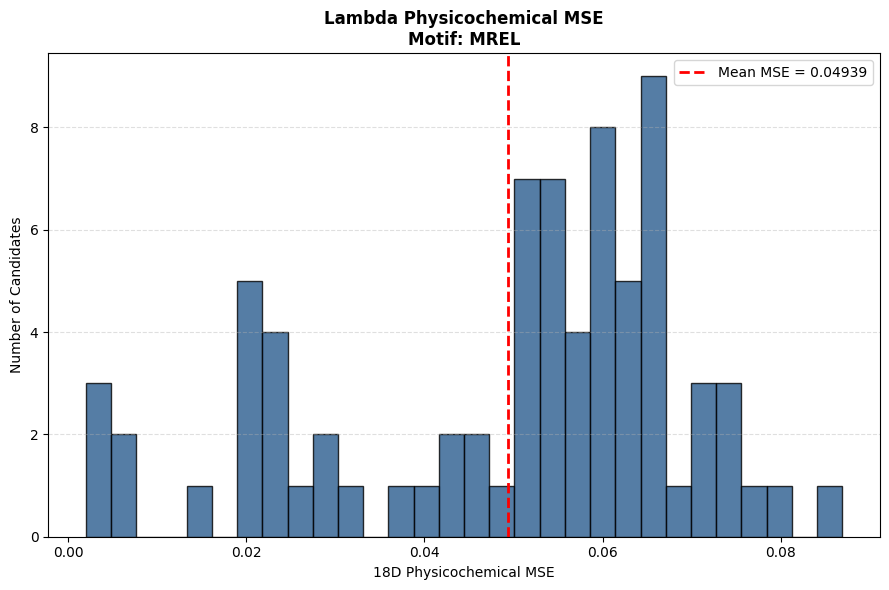

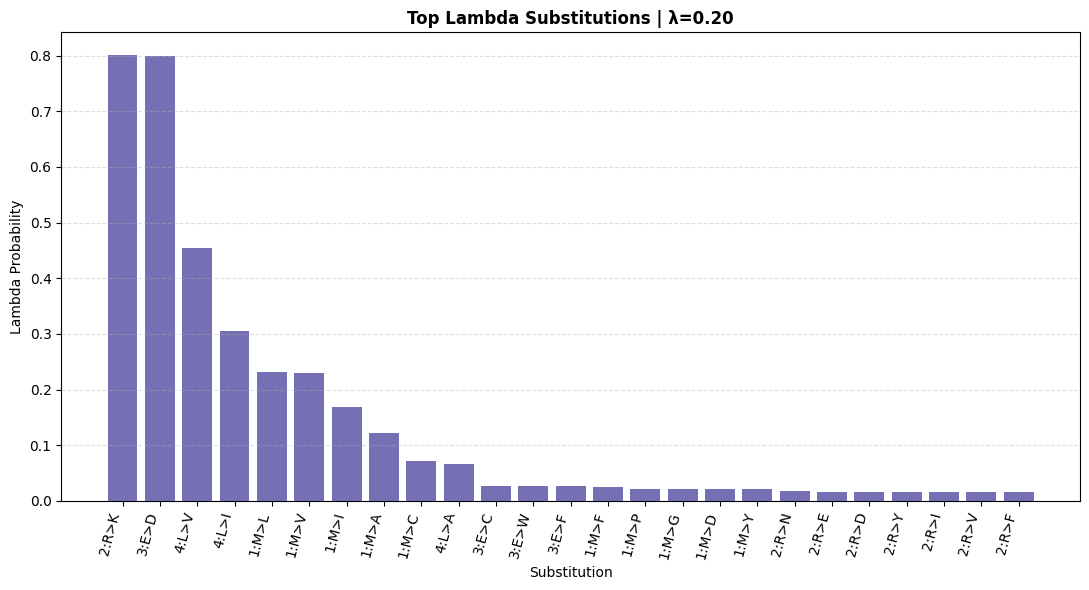

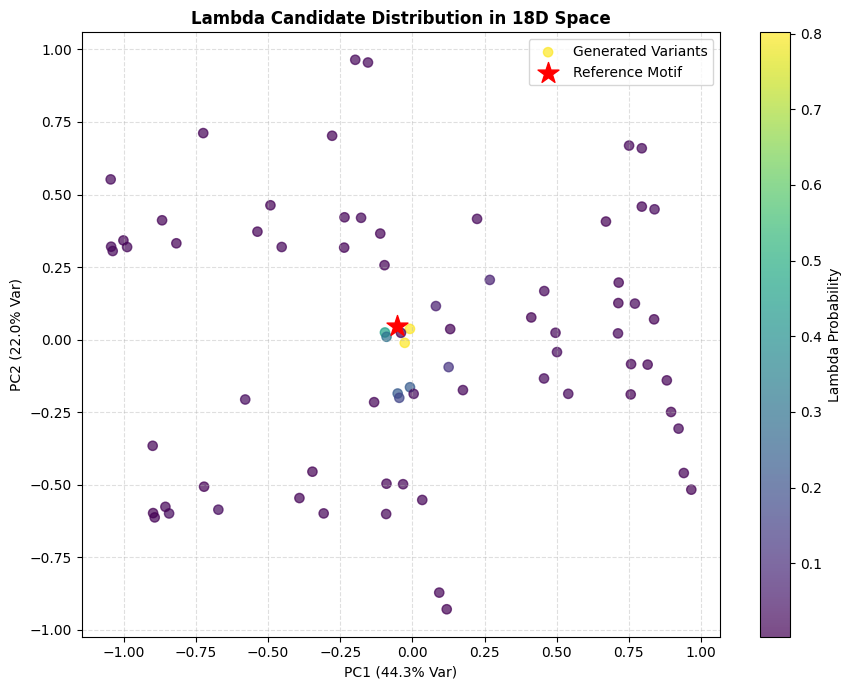


TOP LAMBDA CANDIDATES WITH MSE


,motif,position,from,to,snp_distance,p_dna,p_phys,p_final,mse
0,MKEL,2,R,K,3,0.03020,0.99235,0.80170,0.004057
1,MRDL,3,E,D,3,0.01795,0.99408,0.79991,0.005038
2,MREV,4,L,V,3,0.02871,0.55960,0.45438,0.001988
3,MREI,4,L,I,3,0.02871,0.37357,0.30525,0.002555
4,LREL,1,M,L,3,0.01400,0.28660,0.23232,0.020195
5,VREL,1,M,V,3,0.01400,0.28385,0.23012,0.020235
6,IREL,1,M,I,3,0.01400,0.20618,0.16792,0.021597
7,AREL,1,M,A,1,0.10342,0.12656,0.12205,0.023762
8,CREL,1,M,C,1,0.10342,0.06344,0.07151,0.027002
9,MREA,4,L,A,2,0.07804,0.06316,0.06628,0.005887


In [ ]:
# =============================================================
# USER INPUT
# =============================================================

motif = input(
    "\nEnter a single motif: "
).upper().strip()

if len(motif) == 0:
    raise ValueError(
        "Motif cannot be empty."
    )

invalid = [
    aa for aa in motif
    if aa not in AA_IDX
]

if invalid:
    raise ValueError(
        f"Invalid amino acid(s): {invalid}"
    )


# =============================================================
# LAMBDA PARAMETER
# =============================================================

try:
    lam = float(
        input(
            "Lambda [0=physical, "
            "0.5=equal, 1=DNA]: "
        )
    )
except ValueError:
    lam = 0.5

lam = max(
    0.0,
    min(1.0, lam)
)


# =============================================================
# RUN LAMBDA MODEL
# =============================================================

results = lambda_model(
    motif,
    lam=lam
)


# =============================================================
# RESULTS TABLE
# =============================================================

print(
    "\n" + "=" * 90
)

print(
    "LAMBDA MODEL"
)

print(
    "=" * 90
)

print(
    f"Input motif: {motif}"
)

print(
    f"Lambda: {lam:.3f}"
)

print(
    f"Total substitutions: {len(results)}"
)

print(
    "=" * 90
)


results_df = pd.DataFrame(
    results
)

display(
    results_df.head(25).style.format({
        "p_dna": "{:.5f}",
        "p_phys": "{:.5f}",
        "p_final": "{:.5f}"
    })
)


# =============================================================
# 18D MSE
# =============================================================

ref_18d = motif_to_18d(
    motif
)

generated_18d = np.array([
    motif_to_18d(x)
    for x in results_df["motif"]
])

mse_values = calculate_motif_mse(
    ref_18d,
    generated_18d
)

results_df["mse"] = mse_values


# =============================================================
# MSE PLOT
# =============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    mse_values,
    bins=30,
    color="#2b5c8f",
    alpha=0.8,
    edgecolor="black"
)

plt.axvline(
    np.mean(mse_values),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean MSE = {np.mean(mse_values):.5f}"
)

plt.xlabel(
    "18D Physicochemical MSE"
)

plt.ylabel(
    "Number of Candidates"
)

plt.title(
    f"Lambda Physicochemical MSE\n"
    f"Motif: {motif}",
    fontsize=12,
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "Lambda_MSE_Distribution.png",
    dpi=300
)

plt.show()


# =============================================================
# LAMBDA PROBABILITY PLOT
# =============================================================

top_results = results_df.head(25)

labels = [
    f"{row['position']}:{row['from']}>{row['to']}"
    for _, row in top_results.iterrows()
]

plt.figure(
    figsize=(11, 6)
)

plt.bar(
    labels,
    top_results["p_final"],
    color="#7570b3"
)

plt.xlabel(
    "Substitution"
)

plt.ylabel(
    "Lambda Probability"
)

plt.title(
    f"Top Lambda Substitutions | "
    f"λ={lam:.2f}",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "Lambda_Top_Substitutions.png",
    dpi=300
)

plt.show()


# =============================================================
# PCA OF 18D PHYSICOCHEMICAL SPACE
# =============================================================

all_features = np.vstack([
    generated_18d,
    ref_18d
])

pca = PCA(
    n_components=2
)

coords_2d = pca.fit_transform(
    all_features
)

gen_coords = coords_2d[:-1]
ref_coord = coords_2d[-1]


plt.figure(
    figsize=(9, 7)
)

scatter = plt.scatter(
    gen_coords[:, 0],
    gen_coords[:, 1],
    c=results_df["p_final"],
    cmap="viridis",
    alpha=0.7,
    s=45,
    label="Generated Variants"
)

plt.colorbar(
    scatter,
    label="Lambda Probability"
)

plt.scatter(
    ref_coord[0],
    ref_coord[1],
    color="red",
    marker="*",
    s=250,
    label="Reference Motif"
)

plt.title(
    "Lambda Candidate Distribution in 18D Space",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% Var)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% Var)"
)

plt.legend(
    loc="upper right"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "Lambda_Latent_Space_Distribution.png",
    dpi=300
)

plt.show()


# =============================================================
# FINAL TABLE WITH MSE
# =============================================================

print(
    "\n" + "=" * 90
)

print(
    "TOP LAMBDA CANDIDATES WITH MSE"
)

print(
    "=" * 90
)

display(
    results_df[
        [
            "motif",
            "position",
            "from",
            "to",
            "snp_distance",
            "p_dna",
            "p_phys",
            "p_final",
            "mse"
        ]
    ].head(25).style.format({
        "p_dna": "{:.5f}",
        "p_phys": "{:.5f}",
        "p_final": "{:.5f}",
        "mse": "{:.6f}"
    })
)
